In [25]:
import math
import random
import warnings
import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from collections import defaultdict, Counter
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore', message='.*sklearn.utils.parallel.delayed.*', category=UserWarning)

In [26]:
class BaseRecommender(ABC):
    def __init__(self, name):
        self.name = name
        self.train_df = None
        
    @abstractmethod
    def fit(self, train_df):
        """Treina o modelo com os dados de treino."""
        pass
    
    @abstractmethod
    def recommend(self, author_id, top_n=10):
        """Retorna uma lista de author_ids recomendados."""
        pass

In [27]:
class TopologyRecommender(BaseRecommender):
    def __init__(self):
        super().__init__("Topology (Graph Coauthor)")
        self.graph = defaultdict(set)
        self.popular_authors = []
        
    def fit(self, train_df):
        self.train_df = train_df
        print(f"[{self.name}] Construindo grafo...")
        
        # Construção do Grafo
        for _, group in train_df.groupby('work_id'):
            authors = group['author_id'].tolist()
            if len(authors) > 1:
                for u, v in itertools.combinations(authors, 2):
                    self.graph[u].add(v)
        
        # Cálculo de Popularidade (para fallback)
        popularity_counter = Counter()
        for author, neighbors in self.graph.items():
            popularity_counter[author] = len(neighbors)
        self.popular_authors = [auth for auth, _ in popularity_counter.most_common()]
        print(f"[{self.name}] Grafo construído com {len(self.graph)} autores.")

    def recommend(self, author_id, top_n=10):
        recommendations = []
        current_coauthors = self.graph.get(author_id, set())
        
        if author_id in self.graph:
            candidates = []
            for neighbor in current_coauthors:
                neighbors_of_neighbor = self.graph.get(neighbor, set())
                for candidate in neighbors_of_neighbor:
                    if candidate != author_id and candidate not in current_coauthors:
                        candidates.append(candidate)
      
            recommendations = [c[0] for c in Counter(candidates).most_common(top_n)]
        
        # Fallback: Populares
        if len(recommendations) < top_n:
            for pop in self.popular_authors:
                if pop != author_id and pop not in recommendations and pop not in current_coauthors:
                    recommendations.append(pop)
                    if len(recommendations) >= top_n:
                        break
        
        return recommendations

In [28]:
class IdealTopologyRecommender(BaseRecommender):
    def __init__(self, base_topology_model, ground_truth):
        super().__init__("Ideal Topology (Oracle)")
        self.base_model = base_topology_model
        self.ground_truth = ground_truth
        
    def fit(self, train_df):
        pass
        
    def recommend(self, author_id, top_n=10):
        all_possible_candidates = self.base_model.recommend(author_id, top_n=5000)
        
        actual_future_coauthors = self.ground_truth.get(author_id, set())
        
        perfect_hits = [c for c in all_possible_candidates if c in actual_future_coauthors]
        the_rest = [c for c in all_possible_candidates if c not in actual_future_coauthors]
        
        ideal_recommendation = perfect_hits + the_rest
        
        return ideal_recommendation[:top_n]

In [29]:
class HybridCoauthorRecommender(BaseRecommender):
    def __init__(self, candidate_pool_size=100, n_estimators=100):
        super().__init__("Hybrid (Graph + RandomForest)")
        self.graph = defaultdict(set)
        self.popular_authors = []
        self.rf_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
        self.candidate_pool_size = candidate_pool_size
        
    def _build_graph(self, train_df):
        """Constrói o grafo bidirecional de coautorias."""
        for _, group in train_df.groupby("work_id"):
            authors = group["author_id"].tolist()
            if len(authors) > 1:
                for a, b in itertools.combinations(authors, 2):
                    self.graph[a].add(b)
                    self.graph[b].add(a) 
                    
        # Popularidade para fallback
        popularity_counter = Counter({a: len(neighbors) for a, neighbors in self.graph.items()})
        self.popular_authors = [auth for auth, _ in popularity_counter.most_common()]

    def _extract_features(self, u, v):
        """Calcula features topológicas entre dois autores."""
        neighbors_u = self.graph.get(u, set())
        neighbors_v = self.graph.get(v, set())
        
        common_neighbors = neighbors_u & neighbors_v
        union_neighbors = neighbors_u | neighbors_v
        
        # Feature 1: Common Neighbors (Contagem bruta)
        cn_score = len(common_neighbors)
        
        # Feature 2: Jaccard Similarity (Proporção)
        jaccard_score = cn_score / len(union_neighbors) if len(union_neighbors) > 0 else 0
        
        # Feature 3: Adamic-Adar Index (Peso aos vizinhos menos populares)
        aa_score = 0
        for z in common_neighbors:
            degree_z = len(self.graph.get(z, set()))
            if degree_z > 1: # Evitar divisão por zero ou log(1)
                aa_score += 1 / math.log(degree_z)
                
        return [cn_score, jaccard_score, aa_score]

    def _generate_training_data(self):
        """Gera o dataset para treinar a Random Forest (Amostras Positivas e Negativas)."""
        X = []
        y = []
        
        positive_edges = set()
        for u, neighbors in self.graph.items():
            for v in neighbors:
                if u < v:
                    positive_edges.add((u, v))
        
        positive_edges = list(positive_edges)
        
        max_samples = min(len(positive_edges), 100000) 
        sampled_positives = random.sample(positive_edges, max_samples)
        
        for u, v in sampled_positives:
            X.append(self._extract_features(u, v))
            y.append(1)
            
        print(f"[{self.name}] Gerando amostras negativas...")
        negatives_generated = 0
        
        while negatives_generated < max_samples:
            u = random.choice(list(self.graph.keys()))
            neighbors_u = self.graph.get(u, set())
            
            if not neighbors_u:
                continue
                
            # Pega um vizinho do vizinho (2-hop)
            neighbor = random.choice(list(neighbors_u))
            neighbors_of_neighbor = self.graph.get(neighbor, set())
            
            if not neighbors_of_neighbor:
                continue
                
            v = random.choice(list(neighbors_of_neighbor))
            
            # Condição crucial: u e v não podem ser a mesma pessoa e não podem ser coautores diretos
            if u != v and v not in neighbors_u:
                X.append(self._extract_features(u, v))
                y.append(0)
                negatives_generated += 1
                
        return np.array(X), np.array(y)

    def fit(self, train_df):
        self._build_graph(train_df)
        X_train, y_train = self._generate_training_data()
        self.rf_model.fit(X_train, y_train)

    def recommend(self, author_id, top_n=10):
        current_coauthors = self.graph.get(author_id, set())
        candidate_scores = Counter()
        
        # Busca em 2-hops
        for neighbor in current_coauthors:
            for candidate in self.graph.get(neighbor, set()):
                if candidate != author_id and candidate not in current_coauthors:
                    candidate_scores[candidate] += 1
                    
        # Pega os Top-K candidatos mais promissores
        top_candidates = [c for c, _ in candidate_scores.most_common(self.candidate_pool_size)]
        
        if top_candidates:
            X_candidates = [self._extract_features(author_id, candidate) for candidate in top_candidates]
            
            probabilities = self.rf_model.predict_proba(X_candidates)[:, 1]
            
            scored_candidates = list(zip(top_candidates, probabilities))
            scored_candidates.sort(key=lambda x: x[1], reverse=True)
            
            recommendations = [candidate for candidate, prob in scored_candidates]
        else:
            recommendations = []
            
        # Fallback: Completar com populares se não houver candidatos suficientes
        if len(recommendations) < top_n:
            for pop in self.popular_authors:
                if pop != author_id and pop not in recommendations and pop not in current_coauthors:
                    recommendations.append(pop)
                    if len(recommendations) >= top_n:
                        break
                        
        return recommendations[:top_n]

In [30]:
database_path = '../database_50k'
authors_df = pd.read_csv(f'{database_path}/authorships.csv')
works_df = pd.read_csv(f'{database_path}/works.csv')

merged_df = authors_df.merge(
    works_df[['id', 'publication_date', 'title', 'abstract', 'language']], 
    left_on='work_id', right_on='id'
)
merged_df['publication_date'] = pd.to_datetime(merged_df['publication_date'], errors='coerce')
merged_df = merged_df.dropna(subset=['publication_date', 'author_id', 'title', 'abstract', 'language']).drop(columns=['id'])
merged_df = merged_df[merged_df['language'] == 'en']
merged_df = merged_df[merged_df['publication_date'].dt.year >= 2004]

unique_works = merged_df[['work_id', 'publication_date']].drop_duplicates().sort_values('publication_date')
total_works = len(unique_works)

split_train = int(total_works * 0.8)

train_work_ids = set(unique_works.iloc[:split_train]['work_id'])
test_work_ids = set(unique_works.iloc[split_train:]['work_id'])

train_df = merged_df[merged_df['work_id'].isin(train_work_ids)]
test_df = merged_df[merged_df['work_id'].isin(test_work_ids)]

print(f"\n=== RESUMO DO SPLIT ===")
print(f"Trabalhos no Treino: {len(train_work_ids)}")
print(f"Trabalhos no Teste: {len(test_work_ids)}")
print(f"Total de Autores no Treino: {len(set(train_df['author_id']))}")
print(f"Total de Autores no Teste: {len(set(test_df['author_id']))}")

def build_graph(df):
    graph = defaultdict(set)
    for _, group in df.groupby('work_id'):
        authors = group['author_id'].tolist()
        
        if len(authors) > 1:
            for u, v in itertools.combinations(authors, 2):
                graph[u].add(v)

    return graph

# Construir grafos para avaliação
train_graph = build_graph(train_df)
test_graph_raw = build_graph(test_df)

# Ground truth para teste: novos links que apareceram no teste mas não no treino
test_ground_truth = defaultdict(set)
for author, coauthors in test_graph_raw.items():
    future_coauthors = coauthors
    past_coauthors = train_graph.get(author, set())
    new_links = future_coauthors - past_coauthors
    
    if new_links:
        test_ground_truth[author] = new_links

print(f"\nAutores alvo no teste (com novos links): {len(test_ground_truth)}")

C:\Users\BSBCo\AppData\Local\Temp\ipykernel_23748\615030455.py:3: DtypeWarning: Columns (0: is_retracted) have mixed types. Specify dtype option on import or set low_memory=False.
  works_df = pd.read_csv(f'{database_path}/works.csv')



=== RESUMO DO SPLIT ===
Trabalhos no Treino: 18149
Trabalhos no Teste: 4538
Total de Autores no Treino: 23414
Total de Autores no Teste: 10713

Autores alvo no teste (com novos links): 9354


In [31]:
def calculate_ndcg(recommended_list, relevant_set, k):
    """
    Calcula o NDCG@k (Normalized Discounted Cumulative Gain).

    Args:
        recommended_list: Lista de itens recomendados (ordenados)
        relevant_set: Conjunto de itens relevantes (ground truth)
        k: Número de itens a considerar (top-k)

    Returns:
        NDCG@k score (0.0 a 1.0)
    """
    if len(relevant_set) == 0:
        return 0.0

    # DCG: Discounted Cumulative Gain
    dcg = 0.0
    for i, item in enumerate(recommended_list[:k], 1):
        if item in relevant_set:
            dcg += 1.0 / np.log2(i + 1)

    # IDCG: Ideal DCG (ordenando os relevantes primeiro)
    idcg = 0.0
    num_relevant = min(len(relevant_set), k)
    for i in range(1, num_relevant + 1):
        idcg += 1.0 / np.log2(i + 1)

    # NDCG = DCG / IDCG
    if idcg == 0:
        return 0.0
    return dcg / idcg


def calculate_mrr_at_k(recommended_list, relevant_set, k):
    """
    Calcula o MRR@k (Mean Reciprocal Rank at k).

    O MRR@k só considera o primeiro item relevante se ele aparecer dentro das
    primeiras k posições. Se o primeiro relevante aparecer após a posição k,
    o MRR@k é 0.

    Args:
        recommended_list: Lista de itens recomendados (ordenados)
        relevant_set: Conjunto de itens relevantes (ground truth)
        k: Número máximo de posições a considerar (top-k)

    Returns:
        Reciprocal Rank@k (1/rank do primeiro relevante dentro de k, ou 0 se nenhum relevante)
    """
    if len(relevant_set) == 0:
        return 0.0

    # Considera apenas as primeiras k posições
    for rank, item in enumerate(recommended_list[:k], 1):
        if item in relevant_set:
            return 1.0 / rank

    return 0.0


def evaluate_models(models, test_ground_truth, train_graph_check, K_values=[5, 10]):
    results = {}

    max_k_eval = max(K_values)

    search_limit = max_k_eval * 3

    for model in models:
        print(f"\nAvaliando modelo: {model.name}...")
        model_metrics = {
            k: {"precision": [], "recall": [], "ndcg": [], "mrr": []} for k in K_values
        }

        total_authors = len(test_ground_truth)
        for author_id, actual_new_coauthors in tqdm(
            test_ground_truth.items(),
            desc=f"  {model.name}",
            total=total_authors,
            unit="autor",
        ):
            recs = model.recommend(author_id, top_n=search_limit)

            past_coauthors = train_graph_check.get(author_id, set())
            valid_recs = [r for r in recs if r not in past_coauthors]

            valid_recs = valid_recs[:max_k_eval]

            for k in K_values:
                top_k_recs = valid_recs[:k]

                hits = len(set(top_k_recs) & actual_new_coauthors)

                # Métricas padrão
                p = hits / k if k > 0 else 0
                r = (
                    hits / len(actual_new_coauthors)
                    if len(actual_new_coauthors) > 0
                    else 0
                )
                ndcg = calculate_ndcg(top_k_recs, actual_new_coauthors, k)
                mrr = calculate_mrr_at_k(
                    valid_recs, actual_new_coauthors, k
                ) 

                model_metrics[k]["precision"].append(p)
                model_metrics[k]["recall"].append(r)
                model_metrics[k]["ndcg"].append(ndcg)
                model_metrics[k]["mrr"].append(mrr)

        # Consolidação dos resultados (Média)
        results[model.name] = {}
        for k in K_values:
            avg_p = np.mean(model_metrics[k]["precision"])
            avg_r = np.mean(model_metrics[k]["recall"])
            avg_ndcg = np.mean(model_metrics[k]["ndcg"])
            avg_mrr = np.mean(model_metrics[k]["mrr"])
            f1 = 2 * (avg_p * avg_r) / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0

            results[model.name][k] = {
                "P": avg_p,
                "R": avg_r,
                "F1": f1,
                "NDCG": avg_ndcg,
                "MRR": avg_mrr,
            }

    return results

def plot_model_comparison(results, figsize=(25, 5)):
    model_names = list(results.keys())
    k_values = sorted([k for k in results[model_names[0]].keys() if isinstance(k, int)])
    
    # Preparar dados para cada métrica
    metrics_data = {
        'Precision': {model: [results[model][k]['P'] for k in k_values] for model in model_names},
        'Recall': {model: [results[model][k]['R'] for k in k_values] for model in model_names},
        'F1-Score': {model: [results[model][k]['F1'] for k in k_values] for model in model_names},
        'NDCG': {model: [results[model][k]['NDCG'] for k in k_values] for model in model_names},
        'MRR@k': {model: [results[model][k]['MRR'] for k in k_values] for model in model_names}
    }
    
    # Criar figura com 5 subplots para métricas dependentes de K
    fig, axes = plt.subplots(1, 5, figsize=figsize)
    fig.suptitle('Comparação de Modelos de Link Prediction', fontsize=16, fontweight='bold')
    
    # Cores e estilos para cada modelo
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    markers = ['o', 's', '^', 'D', 'v']
    
    # Plotar cada métrica dependente de K
    for idx, (metric_name, data) in enumerate(metrics_data.items()):
        ax = axes[idx]
        
        for i, model in enumerate(model_names):
            ax.plot(
                k_values, 
                data[model], 
                marker=markers[i % len(markers)],
                label=model,
                color=colors[i % len(colors)],
                linewidth=2,
                markersize=8
            )
        
        ax.set_xlabel('K (Top-K)', fontsize=11)
        ax.set_ylabel(metric_name, fontsize=11)
        ax.set_title(f'{metric_name} por K', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=9)
        ax.set_xticks(k_values)
        
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_model_comparison_results(metrics):
    results_rows = []

    for model_name, ks in metrics.items():
        for k, vals in ks.items():
            results_rows.append({
                'Modelo': model_name,
                'K': k,
                'Precision': vals['P'],
                'Recall': vals['R'],
                'F1': vals['F1'],
                'NDCG': vals['NDCG'],
                'MRR': vals['MRR'],
            })

    results_df = pd.DataFrame(results_rows).sort_values(['Modelo', 'K'])

    metric_cols = ['Precision', 'Recall', 'F1', 'NDCG', 'MRR']
    results_df[metric_cols] = results_df[metric_cols].round(4)

    print(results_df.to_string(index=False))

In [32]:
topo_model = TopologyRecommender()
topo_model.fit(train_df),
topo_metrics = evaluate_models([topo_model], test_ground_truth, train_graph, K_values=[5, 10, 20, 50, 100, 200])

[Topology (Graph Coauthor)] Construindo grafo...
[Topology (Graph Coauthor)] Grafo construído com 20971 autores.

Avaliando modelo: Topology (Graph Coauthor)...


  Topology (Graph Coauthor): 100%|██████████| 9354/9354 [00:23<00:00, 399.76autor/s]


In [33]:
hybrid_model = HybridCoauthorRecommender()
hybrid_model.fit(train_df)
hybrid_metrics = evaluate_models([hybrid_model], test_ground_truth, train_graph, K_values=[5, 10, 20, 50, 100, 200])

[Hybrid (Graph + RandomForest)] Gerando amostras negativas...

Avaliando modelo: Hybrid (Graph + RandomForest)...


  Hybrid (Graph + RandomForest): 100%|██████████| 9354/9354 [00:57<00:00, 163.11autor/s]


                       Modelo   K  Precision  Recall     F1   NDCG    MRR
Hybrid (Graph + RandomForest)   5     0.0112  0.0139 0.0124 0.0147 0.0260
Hybrid (Graph + RandomForest)  10     0.0111  0.0270 0.0158 0.0195 0.0317
Hybrid (Graph + RandomForest)  20     0.0128  0.0619 0.0212 0.0313 0.0400
Hybrid (Graph + RandomForest)  50     0.0083  0.0957 0.0152 0.0405 0.0434
Hybrid (Graph + RandomForest) 100     0.0050  0.1166 0.0096 0.0453 0.0443
Hybrid (Graph + RandomForest) 200     0.0032  0.1479 0.0062 0.0518 0.0450
    Topology (Graph Coauthor)   5     0.0126  0.0151 0.0137 0.0185 0.0337
    Topology (Graph Coauthor)  10     0.0091  0.0213 0.0127 0.0195 0.0361
    Topology (Graph Coauthor)  20     0.0084  0.0389 0.0138 0.0253 0.0409
    Topology (Graph Coauthor)  50     0.0059  0.0682 0.0109 0.0332 0.0439
    Topology (Graph Coauthor) 100     0.0041  0.0952 0.0079 0.0395 0.0450
    Topology (Graph Coauthor) 200     0.0025  0.1090 0.0049 0.0426 0.0455


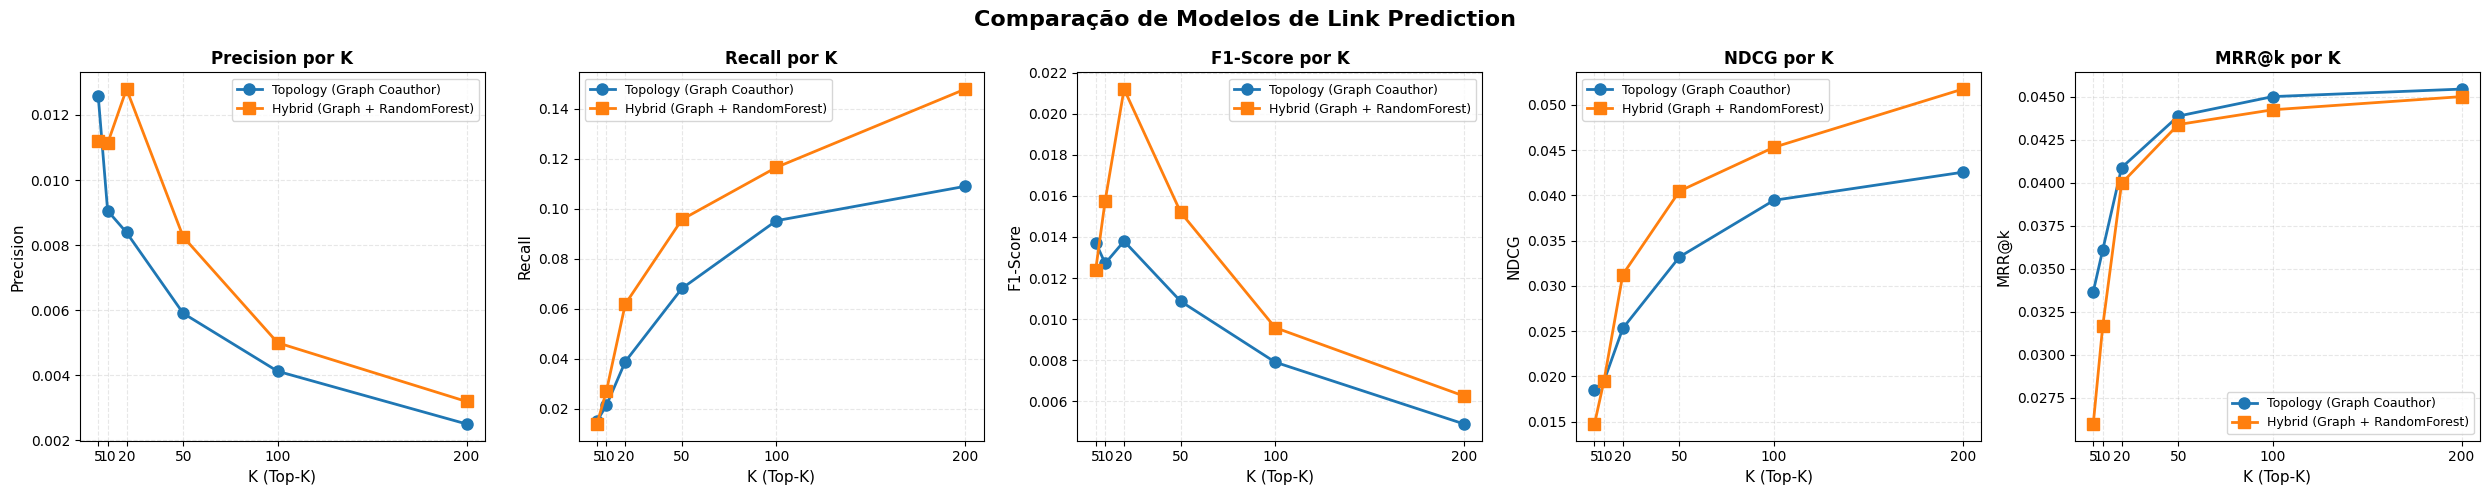

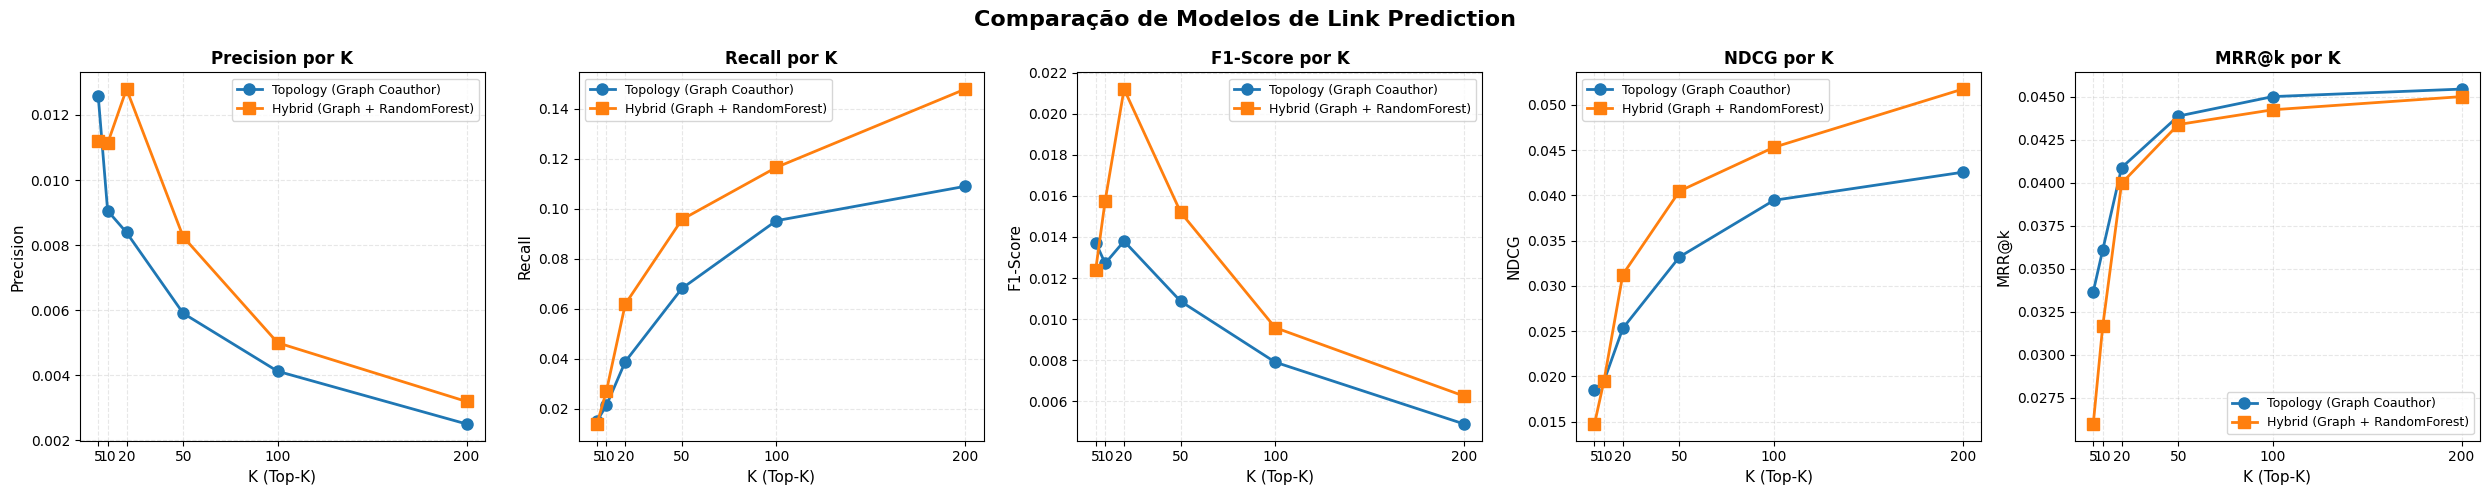

In [34]:
plot_model_comparison_results({**topo_metrics, **hybrid_metrics})
plot_model_comparison({**topo_metrics, **hybrid_metrics})

In [35]:
oracle_model = IdealTopologyRecommender(topo_model, test_ground_truth)
oracle_model.fit(train_df)
oracle_metrics = evaluate_models([oracle_model], test_ground_truth, train_graph, K_values=[5, 10, 20, 50, 100, 200])


Avaliando modelo: Ideal Topology (Oracle)...


  Ideal Topology (Oracle): 100%|██████████| 9354/9354 [29:05<00:00,  5.36autor/s]


                       Modelo   K  Precision  Recall     F1   NDCG    MRR
Hybrid (Graph + RandomForest)   5     0.0112  0.0139 0.0124 0.0147 0.0260
Hybrid (Graph + RandomForest)  10     0.0111  0.0270 0.0158 0.0195 0.0317
Hybrid (Graph + RandomForest)  20     0.0128  0.0619 0.0212 0.0313 0.0400
Hybrid (Graph + RandomForest)  50     0.0083  0.0957 0.0152 0.0405 0.0434
Hybrid (Graph + RandomForest) 100     0.0050  0.1166 0.0096 0.0453 0.0443
Hybrid (Graph + RandomForest) 200     0.0032  0.1479 0.0062 0.0518 0.0450
      Ideal Topology (Oracle)   5     0.2567  0.2821 0.2688 0.4485 0.7425
      Ideal Topology (Oracle)  10     0.1393  0.2858 0.1873 0.4014 0.7425
      Ideal Topology (Oracle)  20     0.0736  0.2874 0.1171 0.3823 0.7425
      Ideal Topology (Oracle)  50     0.0307  0.2885 0.0556 0.3735 0.7425
      Ideal Topology (Oracle) 100     0.0154  0.2885 0.0292 0.3720 0.7425
      Ideal Topology (Oracle) 200     0.0077  0.2885 0.0150 0.3720 0.7425
    Topology (Graph Coauthor)   5     

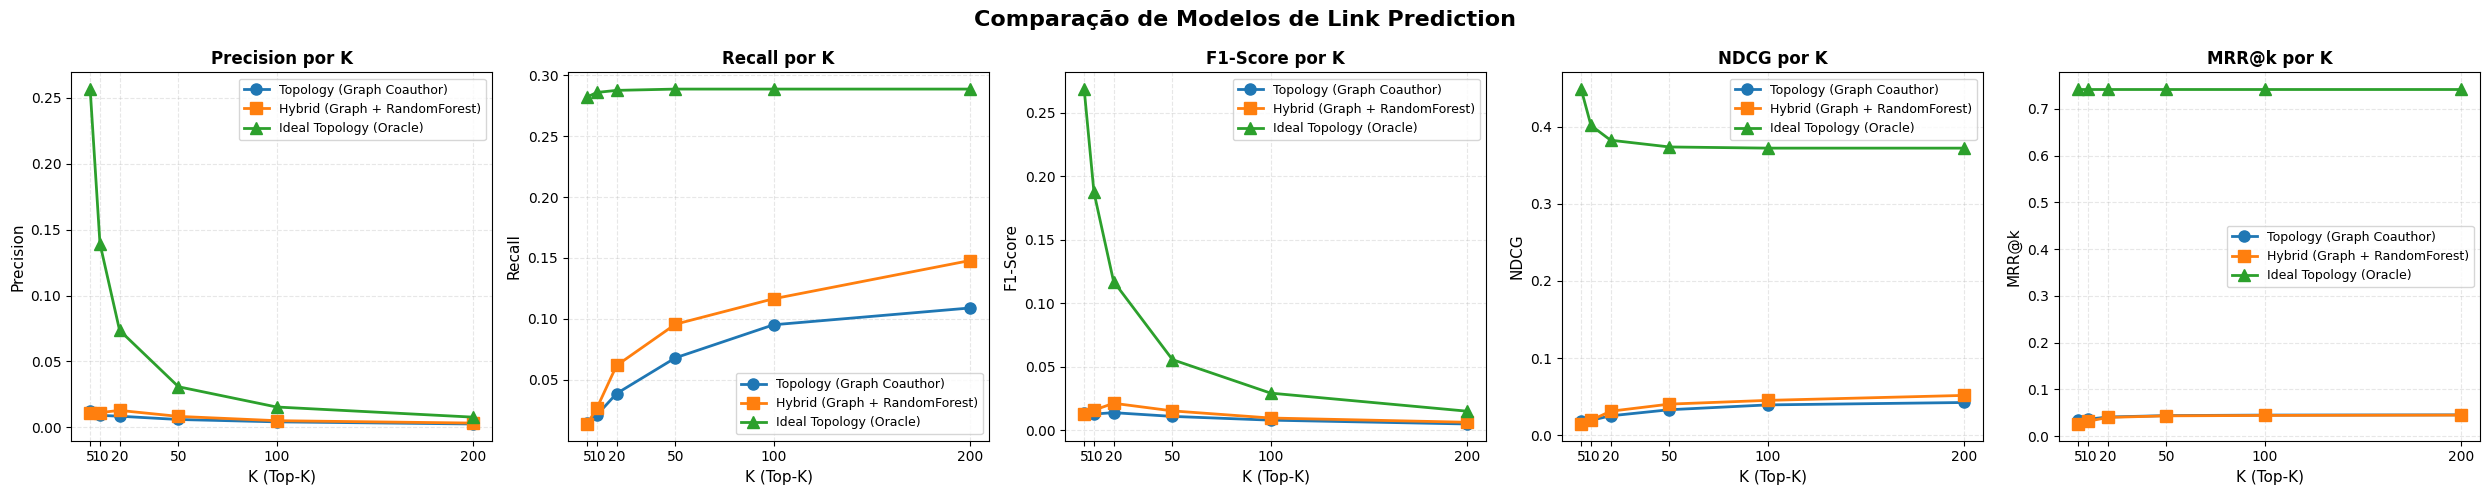

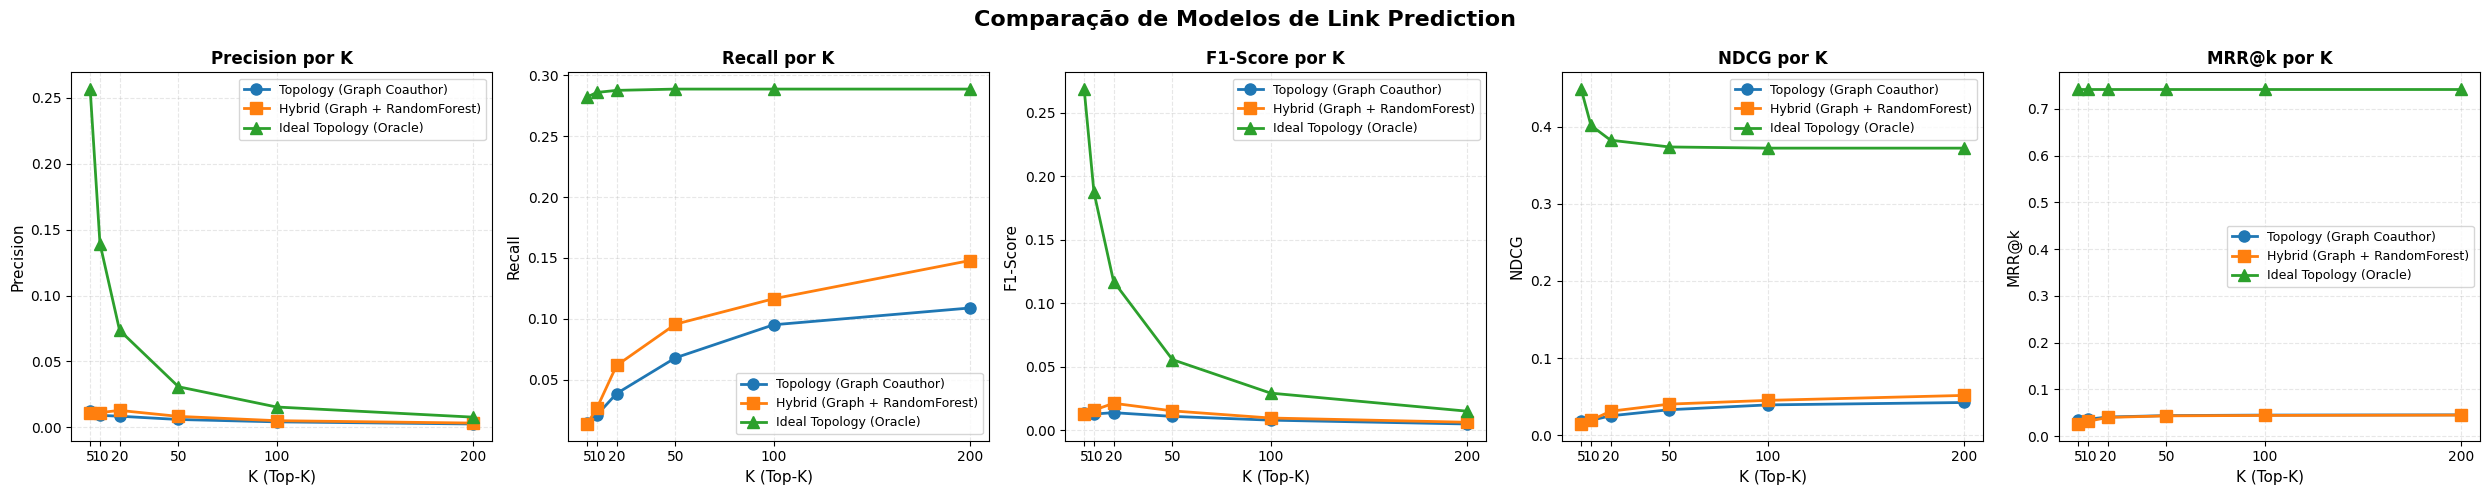

In [36]:
plot_model_comparison_results({**topo_metrics, **hybrid_metrics, **oracle_metrics})
plot_model_comparison({**topo_metrics, **hybrid_metrics, **oracle_metrics})

                   Modelo   K  Precision  Recall     F1   NDCG    MRR
  Ideal Topology (Oracle)   5     0.2567  0.2821 0.2688 0.4485 0.7425
  Ideal Topology (Oracle)  10     0.1393  0.2858 0.1873 0.4014 0.7425
  Ideal Topology (Oracle)  20     0.0736  0.2874 0.1171 0.3823 0.7425
  Ideal Topology (Oracle)  50     0.0307  0.2885 0.0556 0.3735 0.7425
  Ideal Topology (Oracle) 100     0.0154  0.2885 0.0292 0.3720 0.7425
  Ideal Topology (Oracle) 200     0.0077  0.2885 0.0150 0.3720 0.7425
Topology (Graph Coauthor)   5     0.0126  0.0151 0.0137 0.0185 0.0337
Topology (Graph Coauthor)  10     0.0091  0.0213 0.0127 0.0195 0.0361
Topology (Graph Coauthor)  20     0.0084  0.0389 0.0138 0.0253 0.0409
Topology (Graph Coauthor)  50     0.0059  0.0682 0.0109 0.0332 0.0439
Topology (Graph Coauthor) 100     0.0041  0.0952 0.0079 0.0395 0.0450
Topology (Graph Coauthor) 200     0.0025  0.1090 0.0049 0.0426 0.0455


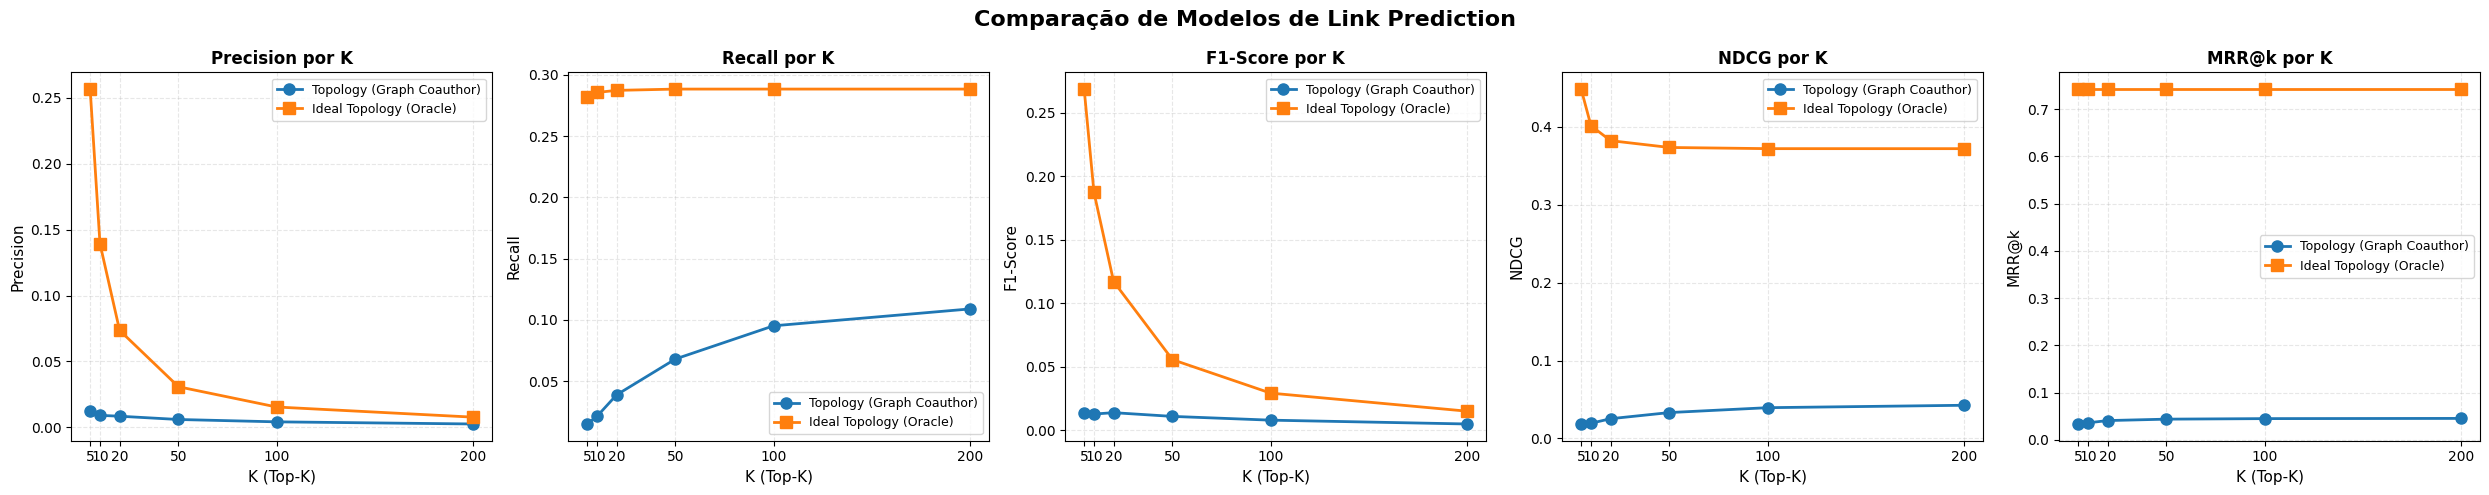

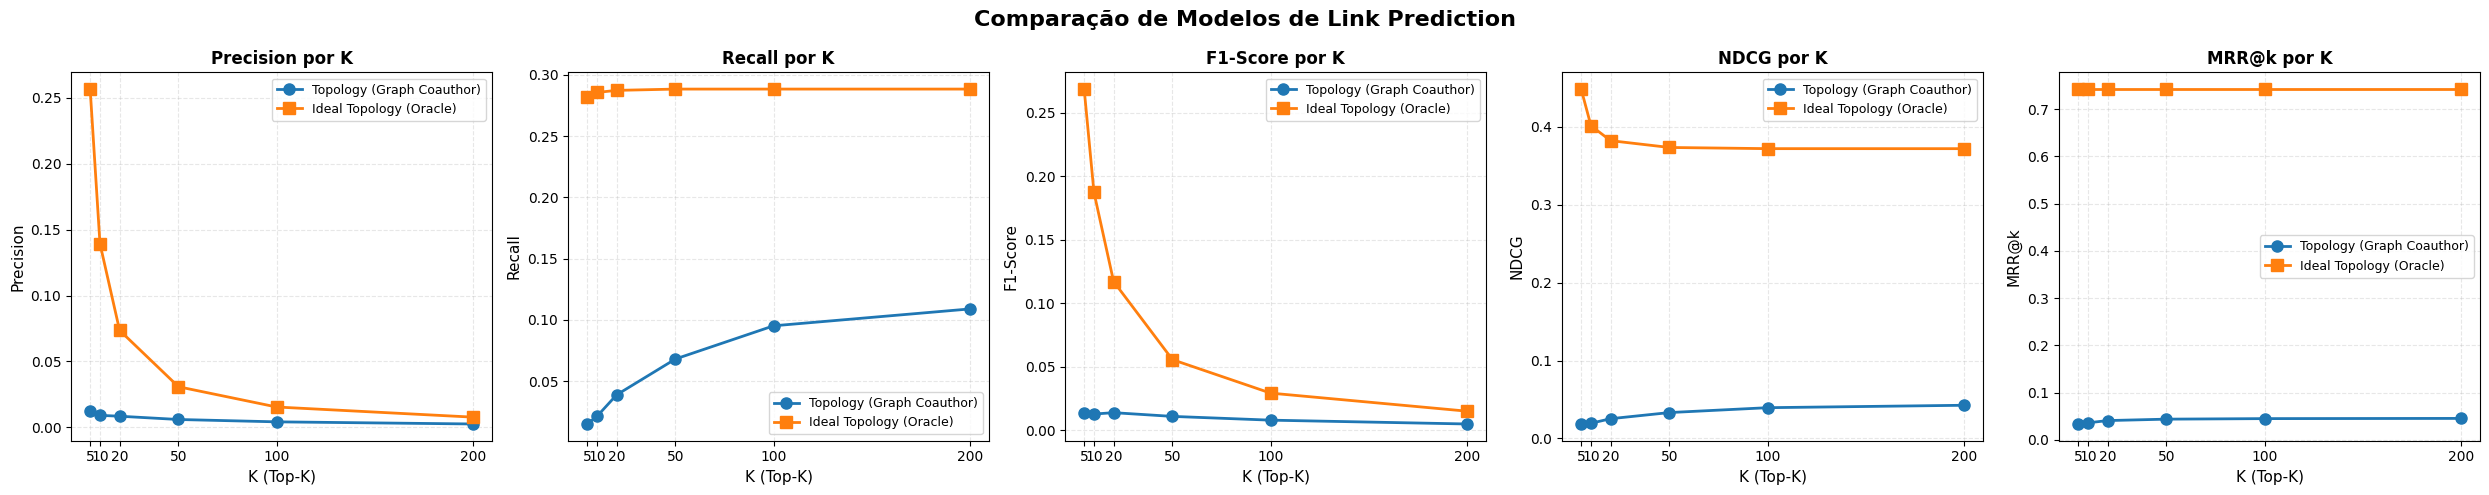

In [37]:
plot_model_comparison_results({**topo_metrics, **oracle_metrics})
plot_model_comparison({**topo_metrics, **oracle_metrics})